
# Comparing a Vision Transformer vs a Convolutional Network Classifying Images from CIFAR-10

### Author: Antonio Rueda-Toicen
#### antonio.rueda.toicen 'at' hpi 'dot' de

This notebook adapts the Vision Transformer (ViT) and a Convolutional Neural Network (CNN)
to the [CIFAR-10](https://en.wikipedia.org/wiki/CIFAR-10) dataset.

We'll explore both architectures, their components,
and discuss their trade-offs.

In [2]:
# Check for NVIDIA GPU availability, should print its specs
!nvidia-smi

Sun Jun 29 21:12:05 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Imports

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets
import torchvision.transforms.v2 as transforms_v2
from torch.utils.data import DataLoader, SubsetRandomSampler, Subset
import matplotlib.pyplot as plt
import numpy as np
import os
import time
from tqdm import tqdm

## Introduction to Vision Transformers (ViT)

Vision Transformers (ViTs) represent a significant shift in computer vision, applying the Transformer architecture, initially successful in Natural Language Processing (NLP), to image recognition tasks.

**Learning Goals:**
*   Gain an overview of the Vision Transformer (ViT) architecture and the self-attention mechanism.
*   Understand tradeoffs between vision transformers and convolutional networks.

**The ViT Architecture Overview:**
The core idea of ViT is to treat an image as a sequence of patches, similar to how words are treated in a sentence.

![](https://github.com/andandandand/images-for-colab-notebooks/blob/main/Screenshot%202024-08-21%20at%2014.14.08.png?raw=true)
*Image from "An Image is Worth 16x16 Words - Transformers for Image Recognition at Scale"*

The process involves:
1.  **Splitting the image into fixed-size patches.**
2.  **Flattening and linearly projecting these patches** into embeddings.
3.  **Adding positional embeddings** to retain spatial information.
4.  **Prepending a learnable `[CLS]` token** to the sequence of patch embeddings. This token's state at the output of the Transformer encoder serves as the image representation for classification.
5.  **Feeding the sequence into a standard Transformer encoder** composed of multiple layers of multi-head self-attention (MHSA) and MLP blocks.
6.  **Using the output `[CLS]` token representation** for classification via an MLP head.

## Load CIFAR-10 Data

CIFAR-10 consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.
We'll apply standard normalization for CIFAR-10 using `transforms.v2`.



In [4]:
# Define transformations for CIFAR-10 using transforms.v2
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2023, 0.1994, 0.2010)

transform_train = transforms_v2.Compose([
    transforms_v2.RandomCrop(32, padding=4),
    transforms_v2.RandomHorizontalFlip(),
    transforms_v2.ToImage(),
    transforms_v2.ToDtype(torch.float32, scale=True),
    transforms_v2.Normalize(cifar10_mean, cifar10_std)
])

transform_test = transforms_v2.Compose([
    transforms_v2.ToImage(),
    transforms_v2.ToDtype(torch.float32, scale=True),
    transforms_v2.Normalize(cifar10_mean, cifar10_std)
])

full_train_dataset = datasets.CIFAR10(root='./data', train=True, transform=transform_train, download=True)
test_dataset_obj = datasets.CIFAR10(root='./data', train=False, transform=transform_test, download=True) # Renamed to avoid conflict

validation_split = 0.1
dataset_size = len(full_train_dataset)
indices = list(range(dataset_size))
split = int(np.floor(validation_split * dataset_size))
np.random.seed(42)
np.random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_indices)

# TransformedSubset class for applying transforms to subsets
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index] # subset itself contains PIL images if original was PIL
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

# For validation, we need the original PIL images from the full_train_dataset, then apply test_transform
# Get raw dataset for validation split
raw_train_dataset_for_val_split = datasets.CIFAR10(root='./data', train=True, transform=None, download=False)
val_subset_pil = Subset(raw_train_dataset_for_val_split, val_indices) # This subset now contains PIL images
val_dataset_transformed = TransformedSubset(val_subset_pil, transform_test) # Apply test_transform

batch_size = 128
train_loader = DataLoader(full_train_dataset, batch_size=batch_size, sampler=train_sampler, num_workers=2)
val_loader = DataLoader(val_dataset_transformed, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset_obj, batch_size=batch_size*2, shuffle=False, num_workers=2)

print(f"Number of training samples: {len(train_indices)}")
print(f"Number of validation samples: {len(val_indices)}")
print(f"Number of test samples: {len(test_dataset_obj)}")

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']




100%|██████████| 170M/170M [00:02<00:00, 60.3MB/s]


Number of training samples: 45000
Number of validation samples: 5000
Number of test samples: 10000


## Visualizing Image Patching (for ViT context)

In [ ]:
def show_image_patches(image_tensor, patch_size=4, class_name="Unknown"):
    unnormalized_image = image_tensor.clone()
    mean = torch.tensor(cifar10_mean).view(3, 1, 1)
    std = torch.tensor(cifar10_std).view(3, 1, 1)
    unnormalized_image = unnormalized_image * std + mean
    unnormalized_image_permuted = unnormalized_image.permute(1, 2, 0).cpu().numpy()
    unnormalized_image_permuted = np.clip(unnormalized_image_permuted, 0, 1)

    C, H, W = image_tensor.shape
    num_patches_h = H // patch_size
    num_patches_w = W // patch_size

    fig = plt.figure(figsize=(num_patches_w * 1.0, num_patches_h * 1.0 + 1.5))
    ax_orig = fig.add_subplot(num_patches_h + 1, 1, 1)
    ax_orig.imshow(unnormalized_image_permuted)
    ax_orig.set_title(f"Original Image (Class: {class_name})")
    ax_orig.axis('off')

    gs = fig.add_gridspec(num_patches_h, num_patches_w, left=0.05, right=0.95, bottom=0.05, top=0.75-(2.5/ (num_patches_h +1)), wspace=0.1, hspace=0.1)
    for i in range(num_patches_h):
        for j in range(num_patches_w):
            patch_display = unnormalized_image_permuted[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size, :]
            ax = fig.add_subplot(gs[i, j])
            ax.imshow(patch_display)
            ax.axis('off')
    plt.suptitle("Image Patches", fontsize=14, y=0.82)
    plt.show()

# sample_image_vis, sample_label_idx_vis = val_dataset_transformed[0]
# sample_label_name_vis = class_names[sample_label_idx_vis]
PATCH_SIZE = 4
# show_image_patches(sample_image_vis, patch_size=PATCH_SIZE, class_name=sample_label_name_vis)



## Defining ViT Components

In [5]:

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, emb_size=128, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, emb_size, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        x = self.proj(x); x = x.flatten(2); x = x.transpose(1, 2); return x

class MultiHeadAttention(nn.Module):
    def __init__(self, emb_size, num_heads, dropout):
        super().__init__(); self.emb_size = emb_size; self.num_heads = num_heads
        self.mha = nn.MultiheadAttention(emb_size, num_heads, dropout=dropout, batch_first=True)
    def forward(self, x): attn_output, _ = self.mha(x, x, x); return attn_output

class MLPBlock(nn.Module):
    def __init__(self, emb_size, mlp_dim, dropout):
        super().__init__()
        self.fc1 = nn.Linear(emb_size, mlp_dim); self.gelu = nn.GELU()
        self.dropout1 = nn.Dropout(dropout); self.fc2 = nn.Linear(mlp_dim, emb_size)
        self.dropout2 = nn.Dropout(dropout)
    def forward(self, x):
        x = self.fc1(x); x = self.gelu(x); x = self.dropout1(x)
        x = self.fc2(x); x = self.dropout2(x); return x

class TransformerEncoderBlock(nn.Module):
    def __init__(self, emb_size, num_heads, mlp_dim, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(emb_size); self.attn = MultiHeadAttention(emb_size, num_heads, dropout)
        self.norm2 = nn.LayerNorm(emb_size); self.mlp = MLPBlock(emb_size, mlp_dim, dropout)
    def forward(self, x):
        x_res1 = x; x = self.norm1(x); x = self.attn(x); x = x + x_res1
        x_res2 = x; x = self.norm2(x); x = self.mlp(x); x = x + x_res2; return x

IMG_SIZE = 32; IN_CHANNELS = 3; EMB_SIZE = 192; NUM_HEADS = 6
MLP_DIM = EMB_SIZE * 2; DROPOUT = 0.1; DEPTH = 6




## Vision Transformer (ViT) Model Assembled



In [12]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, num_classes=10,
                 emb_size=192, depth=6, num_heads=6, mlp_dim=384, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels, patch_size, emb_size, img_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_size))
        self.pos_embedding = nn.Parameter(torch.randn(1, 1 + self.patch_embed.n_patches, emb_size))
        self.pos_dropout = nn.Dropout(dropout)
        self.transformer_encoders = nn.Sequential(*[
            TransformerEncoderBlock(emb_size, num_heads, mlp_dim, dropout) for _ in range(depth)])
        self.norm = nn.LayerNorm(emb_size); self.mlp_head = nn.Linear(emb_size, num_classes)
    def forward(self, x):
        batch_size = x.shape[0]; x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1); x = x + self.pos_embedding; x = self.pos_dropout(x)
        x = self.transformer_encoders(x); cls_token_final_state = x[:, 0]
        x = self.norm(cls_token_final_state); x = self.mlp_head(x); return x

vit_model = VisionTransformer(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=IN_CHANNELS, num_classes=len(class_names),
    emb_size=EMB_SIZE, depth=DEPTH, num_heads=NUM_HEADS, mlp_dim=MLP_DIM, dropout=DROPOUT)

total_params_vit = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f"ViT Total trainable parameters: {total_params_vit:,}")



ViT Total trainable parameters: 1,806,538



## ViT Training Setup

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

vit_model.to(device)
vit_criterion = nn.CrossEntropyLoss()
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=0.001, weight_decay=1e-2)
vit_scheduler = optim.lr_scheduler.CosineAnnealingLR(vit_optimizer, T_max=50) # T_max should ideally be num_epochs
VIT_CHECKPOINT_PATH = "best_vit_cifar10_model.pth"


Using device: cuda


## ViT Training Loop with Validation and Checkpointing


--- Starting ViT Training ---
Epoch 1/25


Validation: 100%|██████████| 40/40 [00:00<00:00, 40.51it/s]


ViT Epoch [1/25], Train Loss: 1.7763, Val Loss: 1.5144, Val Acc: 45.28%
ViT Validation loss improved from inf to 1.5144. Saving model...
Epoch 2/25


Validation: 100%|██████████| 40/40 [00:01<00:00, 39.03it/s]


ViT Epoch [2/25], Train Loss: 1.5364, Val Loss: 1.3802, Val Acc: 50.08%
ViT Validation loss improved from 1.5144 to 1.3802. Saving model...
Epoch 3/25


...

ViT Epoch [23/25], Train Loss: 0.6745, Val Loss: 0.6762, Val Acc: 75.22%
ViT Validation loss improved from 0.6893 to 0.6762. Saving model...
Epoch 24/25


Validation: 100%|██████████| 40/40 [00:01<00:00, 36.89it/s]


ViT Epoch [24/25], Train Loss: 0.6461, Val Loss: 0.6505, Val Acc: 76.98%
ViT Validation loss improved from 0.6762 to 0.6505. Saving model...
Epoch 25/25


Validation: 100%|██████████| 40/40 [00:01<00:00, 39.50it/s]


ViT Epoch [25/25], Train Loss: 0.6222, Val Loss: 0.6521, Val Acc: 76.56%

ViT Training finished. Best validation loss: 0.6505 at epoch 24
ViT Training duration: 616.84 seconds


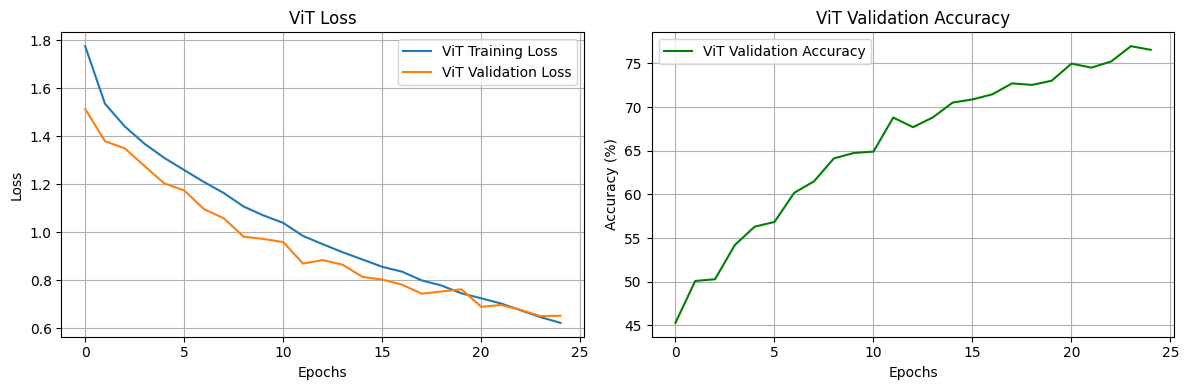

In [14]:
num_epochs = 25 # Same number of epochs for both models
vit_best_val_loss = float('inf')
vit_best_epoch = 0

vit_train_losses, vit_val_losses, vit_val_accuracies = [], [], []

print("--- Starting ViT Training ---")
vit_training_start_time = time.time()

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    vit_model.train()
    running_train_loss = 0.0
    for images, labels in tqdm(train_loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        vit_optimizer.zero_grad(); outputs = vit_model(images)
        loss = vit_criterion(outputs, labels); loss.backward(); vit_optimizer.step()
        running_train_loss += loss.item()
    avg_train_loss = running_train_loss / len(train_loader)
    vit_train_losses.append(avg_train_loss)

    vit_model.eval()
    running_val_loss = 0.0; correct_val = 0; total_val = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = vit_model(images); loss = vit_criterion(outputs, labels)
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0); correct_val += (predicted == labels).sum().item()
    avg_val_loss = running_val_loss / len(val_loader)
    vit_val_losses.append(avg_val_loss)
    val_accuracy = 100 * correct_val / total_val
    vit_val_accuracies.append(val_accuracy)
    print(f'ViT Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

    if avg_val_loss < vit_best_val_loss:
        print(f"ViT Validation loss improved from {vit_best_val_loss:.4f} to {avg_val_loss:.4f}. Saving model...")
        vit_best_val_loss = avg_val_loss; vit_best_epoch = epoch + 1
        torch.save(vit_model.state_dict(), VIT_CHECKPOINT_PATH)
    if vit_scheduler: vit_scheduler.step()

vit_training_end_time = time.time()
vit_training_duration = vit_training_end_time - vit_training_start_time
print(f"\nViT Training finished. Best validation loss: {vit_best_val_loss:.4f} at epoch {vit_best_epoch}")
print(f"ViT Training duration: {vit_training_duration:.2f} seconds")

plt.figure(figsize=(12, 4)); plt.subplot(1, 2, 1)
plt.plot(vit_train_losses, label='ViT Training Loss'); plt.plot(vit_val_losses, label='ViT Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('ViT Loss'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(vit_val_accuracies, label='ViT Validation Accuracy', color='green')
plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)'); plt.title('ViT Validation Accuracy'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()




## ViT Evaluation with the Best Weights Found During Training


In [15]:
if os.path.exists(VIT_CHECKPOINT_PATH):
    print(f"Loading best ViT model from {VIT_CHECKPOINT_PATH} (epoch {vit_best_epoch}) for final evaluation.")
    vit_model.load_state_dict(torch.load(VIT_CHECKPOINT_PATH, map_location=device))
else: print("No ViT checkpoint found. Evaluating with the last ViT model state.")

vit_model.eval(); correct_test_vit = 0; total_test_vit = 0; test_loss_vit_val = 0.0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vit_model(images); loss = vit_criterion(outputs, labels)
        test_loss_vit_val += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_test_vit += labels.size(0); correct_test_vit += (predicted == labels).sum().item()
avg_test_loss_vit = test_loss_vit_val / len(test_loader)
test_accuracy_vit = 100 * correct_test_vit / total_test_vit
print(f'\nBest ViT Model Performance on Test Set:')
print(f'ViT Test Loss: {avg_test_loss_vit:.4f}')
print(f'ViT Test Accuracy: {test_accuracy_vit:.2f} %')

Loading best ViT model from best_vit_cifar10_model.pth (epoch 24) for final evaluation.

Best ViT Model Performance on Test Set:
ViT Test Loss: 0.6776
ViT Test Accuracy: 76.02 %


## ViT Plotting Final Predictions


Visualizing ViT predictions:


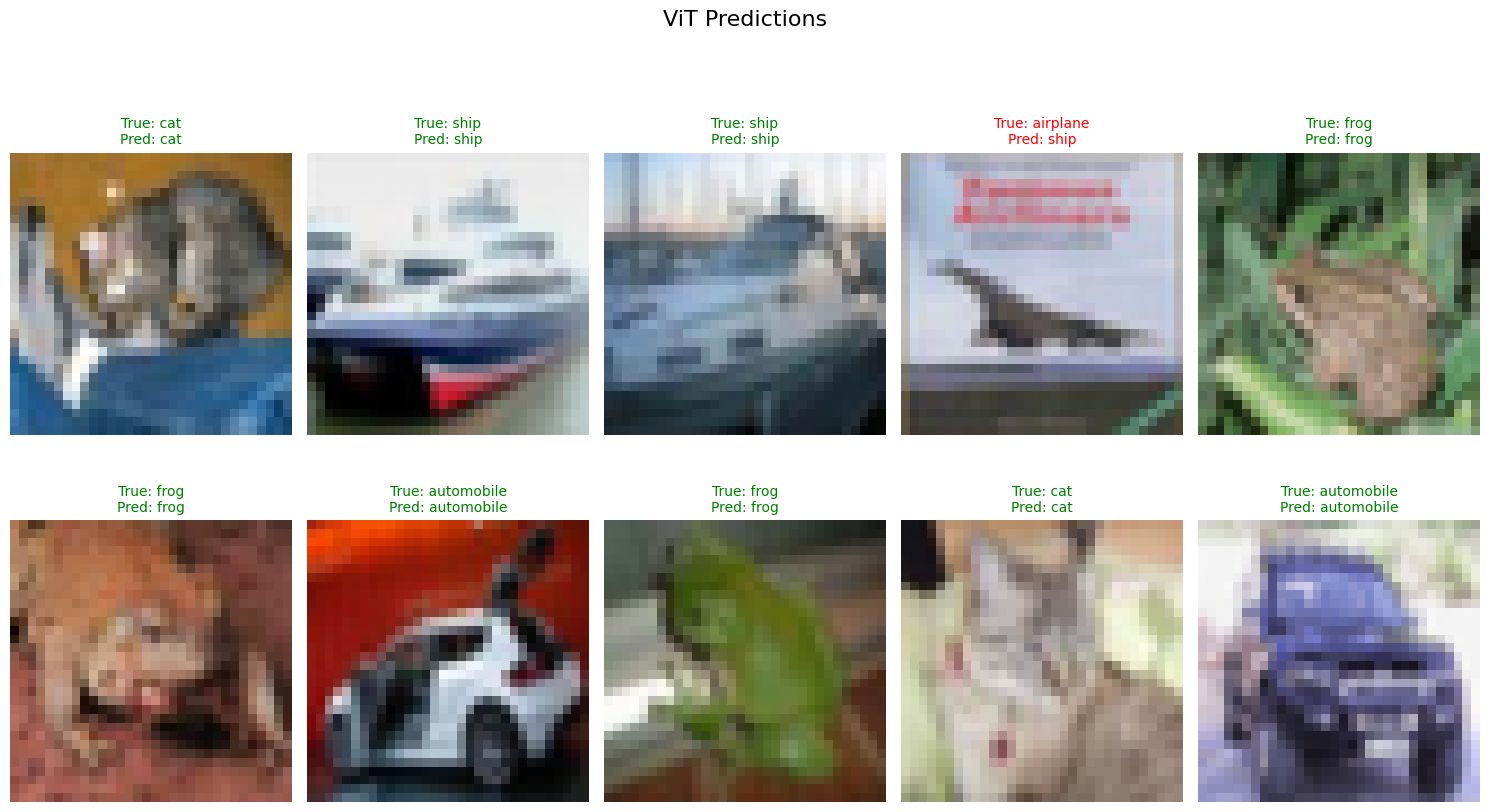

In [16]:
def plot_predictions(model, data_loader, class_names_list, device_in, num_images=10, model_name="Model"): # Added model_name
    model.eval(); images_so_far = 0; fig = plt.figure(figsize=(15, (num_images // 5 + 1) * 3)) # Adjusted fig size
    fig.suptitle(f"{model_name} Predictions", fontsize=16) # Added super title

    dataiter = iter(data_loader)
    try: images, labels = next(dataiter)
    except StopIteration: print("Data loader is empty."); return
    images, labels = images.to(device_in), labels.to(device_in)

    with torch.no_grad(): outputs = model(images); _, preds = torch.max(outputs, 1)
    images_np = images.cpu()

    for i in range(min(num_images, len(images_np))):
        images_so_far += 1
        ax = plt.subplot(num_images // 5 + (num_images % 5 > 0), 5, images_so_far)
        ax.axis('off'); img = images_np[i].clone()
        mean = torch.tensor(cifar10_mean, device=img.device).view(3, 1, 1)
        std = torch.tensor(cifar10_std, device=img.device).view(3, 1, 1)
        img = img * std + mean; img_display = np.clip(img.permute(1, 2, 0).cpu().numpy(), 0, 1)
        ax.imshow(img_display)
        true_label = class_names_list[labels[i].cpu()]; pred_label = class_names_list[preds[i].cpu()]
        title_color = 'green' if pred_label == true_label else 'red'
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=title_color, fontsize=10)
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show() # Adjust layout for suptitle

print("\nVisualizing ViT predictions:")
plot_predictions(vit_model, test_loader, class_names, device, num_images=10, model_name="ViT")

## Convolutional Neural Network (CNN) Model  

We'll define a basic CNN architecture suitable for CIFAR-10.
This network has a few convolutional layers, pooling, and fully connected layers.


In [17]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # Input: 32x32x3
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2) # Output: 16x16x32
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # Input: 16x16x32
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2) # Output: 8x8x64
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # Input: 8x8x64
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2, stride=2) # Output: 4x4x128
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        return x

cnn_model = SimpleCNN(num_classes=len(class_names))
total_params_cnn = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"CNN Total trainable parameters: {total_params_cnn:,}")

# Test with a sample batch
# images_batch_example, _ = next(iter(train_loader)) # Already defined
# cnn_output_example = cnn_model(images_batch_example)
# print(f"CNN Model output shape: {cnn_output_example.shape}")


CNN Total trainable parameters: 1,342,122


## CNN Training Setup

In [18]:
cnn_model.to(device)
cnn_criterion = nn.CrossEntropyLoss() # Can reuse vit_criterion
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001) # Adam is common for CNNs
# cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(cnn_optimizer, 'min', patience=3, factor=0.5) # Example scheduler
cnn_scheduler = None # Keeping it simple like ViT for now for direct comparison
CNN_CHECKPOINT_PATH = "best_cnn_cifar10_model.pth"




## CNN Training Loop with Validation and Checkpointing


--- Starting CNN Training ---
Epoch 1/25


Validation: 100%|██████████| 40/40 [00:01<00:00, 35.88it/s]


CNN Epoch [1/25], Train Loss: 1.4899, Val Loss: 1.0881, Val Acc: 60.08%
CNN Validation loss improved from inf to 1.0881. Saving model...
Epoch 2/25


Validation: 100%|██████████| 40/40 [00:00<00:00, 40.02it/s]


CNN Epoch [2/25], Train Loss: 1.0726, Val Loss: 0.8623, Val Acc: 68.64%
CNN Validation loss improved from 1.0881 to 0.8623. Saving model...
Epoch 3/25


...

CNN Epoch [23/25], Train Loss: 0.3789, Val Loss: 0.4055, Val Acc: 86.22%
Epoch 24/25


Validation: 100%|██████████| 40/40 [00:01<00:00, 39.98it/s]


CNN Epoch [24/25], Train Loss: 0.3747, Val Loss: 0.3957, Val Acc: 87.12%
CNN Validation loss improved from 0.3973 to 0.3957. Saving model...
Epoch 25/25


Validation: 100%|██████████| 40/40 [00:01<00:00, 39.65it/s]


CNN Epoch [25/25], Train Loss: 0.3658, Val Loss: 0.3656, Val Acc: 87.18%
CNN Validation loss improved from 0.3957 to 0.3656. Saving model...

CNN Training finished. Best validation loss: 0.3656 at epoch 25
CNN Training duration: 325.65 seconds


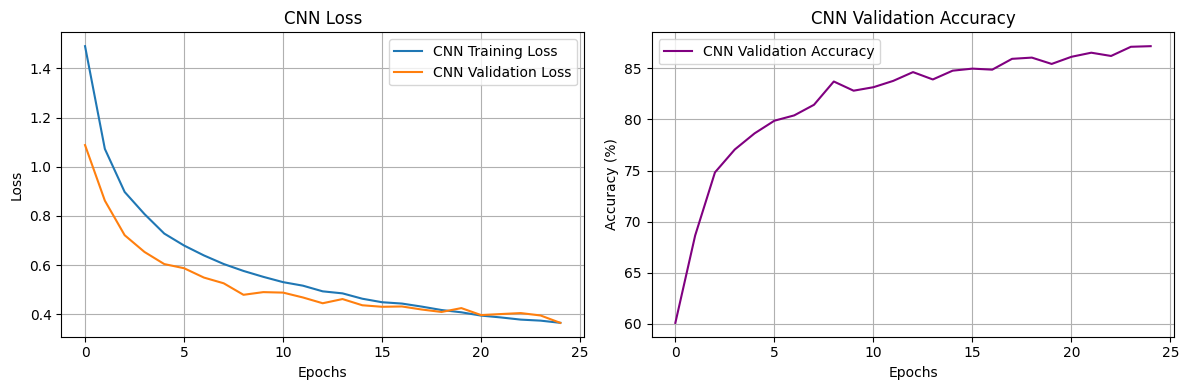

In [19]:
# num_epochs is already defined (e.g., 25)
cnn_best_val_loss = float('inf')
cnn_best_epoch = 0

cnn_train_losses, cnn_val_losses, cnn_val_accuracies = [], [], []

print("\n--- Starting CNN Training ---")
cnn_training_start_time = time.time()

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    cnn_model.train()
    running_train_loss = 0.0
    for images, labels in tqdm(train_loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        cnn_optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = cnn_criterion(outputs, labels)
        loss.backward()
        cnn_optimizer.step()
        running_train_loss += loss.item()
    avg_train_loss = running_train_loss / len(train_loader)
    cnn_train_losses.append(avg_train_loss)

    cnn_model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation'): # Using the same val_loader
            images, labels = images.to(device), labels.to(device)
            outputs = cnn_model(images)
            loss = cnn_criterion(outputs, labels)
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = running_val_loss / len(val_loader)
    cnn_val_losses.append(avg_val_loss)
    val_accuracy = 100 * correct_val / total_val
    cnn_val_accuracies.append(val_accuracy)
    print(f'CNN Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

    if avg_val_loss < cnn_best_val_loss:
        print(f"CNN Validation loss improved from {cnn_best_val_loss:.4f} to {avg_val_loss:.4f}. Saving model...")
        cnn_best_val_loss = avg_val_loss
        cnn_best_epoch = epoch + 1
        torch.save(cnn_model.state_dict(), CNN_CHECKPOINT_PATH)

    # if cnn_scheduler:
    #     if isinstance(cnn_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
    #         cnn_scheduler.step(avg_val_loss)
    #     else:
    #         cnn_scheduler.step()


cnn_training_end_time = time.time()
cnn_training_duration = cnn_training_end_time - cnn_training_start_time
print(f"\nCNN Training finished. Best validation loss: {cnn_best_val_loss:.4f} at epoch {cnn_best_epoch}")
print(f"CNN Training duration: {cnn_training_duration:.2f} seconds")


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_train_losses, label='CNN Training Loss')
plt.plot(cnn_val_losses, label='CNN Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('CNN Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cnn_val_accuracies, label='CNN Validation Accuracy', color='purple')
plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)'); plt.title('CNN Validation Accuracy'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

## CNN Evaluation with the Best Model Weights

In [20]:
if os.path.exists(CNN_CHECKPOINT_PATH):
    print(f"Loading best CNN model from {CNN_CHECKPOINT_PATH} (epoch {cnn_best_epoch}) for final evaluation.")
    cnn_model.load_state_dict(torch.load(CNN_CHECKPOINT_PATH, map_location=device))
else:
    print("No CNN checkpoint found. Evaluating with the last CNN model state.")

cnn_model.eval()
correct_test_cnn = 0
total_test_cnn = 0
test_loss_cnn_val = 0.0
with torch.no_grad():
    for images, labels in test_loader: # Using the same test_loader
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        loss = cnn_criterion(outputs, labels)
        test_loss_cnn_val += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_test_cnn += labels.size(0)
        correct_test_cnn += (predicted == labels).sum().item()

avg_test_loss_cnn = test_loss_cnn_val / len(test_loader)
test_accuracy_cnn = 100 * correct_test_cnn / total_test_cnn
print(f'\nBest CNN Model Performance on Test Set:')
print(f'CNN Test Loss: {avg_test_loss_cnn:.4f}')
print(f'CNN Test Accuracy: {test_accuracy_cnn:.2f} %')



Loading best CNN model from best_cnn_cifar10_model.pth (epoch 25) for final evaluation.

Best CNN Model Performance on Test Set:
CNN Test Loss: 0.4155
CNN Test Accuracy: 86.14 %


'\n## CNN Plotting Final Predictions\n'


## CNN Plotting Final Predictions



In [ ]:
print("\nVisualizing CNN predictions:")
plot_predictions(cnn_model, test_loader, class_names, device, num_images=10, model_name="CNN")


## Model Comparison: ViT vs. CNN

Here we compare the performance of the Vision Transformer (ViT) and the Convolutional Neural Network (CNN)
on the CIFAR-10 test set, along with their training times for the same number of epochs.




--- Performance Comparison ---
Number of Epochs Trained: 25

Vision Transformer (ViT):
  Test Accuracy: 76.02%
  Training Time: 616.84 seconds
  Number of Parameters: 1,806,538

Convolutional Neural Network (CNN):
  Test Accuracy: 86.14%
  Training Time: 325.65 seconds
  Number of Parameters: 1,342,122

--- Overall Training and Validation Curves ---


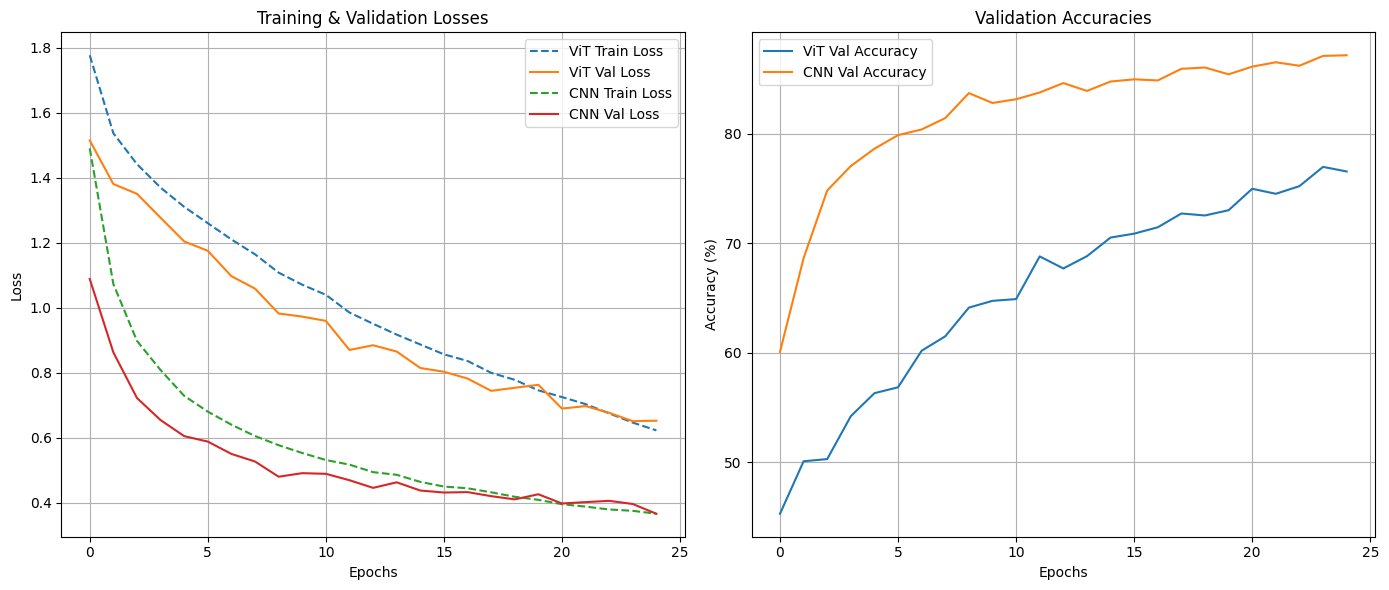

In [21]:
print("--- Performance Comparison ---")
print(f"Number of Epochs Trained: {num_epochs}")

print("\nVision Transformer (ViT):")
print(f"  Test Accuracy: {test_accuracy_vit:.2f}%")
print(f"  Training Time: {vit_training_duration:.2f} seconds")
print(f"  Number of Parameters: {total_params_vit:,}")


print("\nConvolutional Neural Network (CNN):")
print(f"  Test Accuracy: {test_accuracy_cnn:.2f}%")
print(f"  Training Time: {cnn_training_duration:.2f} seconds")
print(f"  Number of Parameters: {total_params_cnn:,}")

print("\n--- Overall Training and Validation Curves ---")
plt.figure(figsize=(14, 6))

# Plot Losses
plt.subplot(1, 2, 1)
plt.plot(vit_train_losses, label='ViT Train Loss', linestyle='--')
plt.plot(vit_val_losses, label='ViT Val Loss')
plt.plot(cnn_train_losses, label='CNN Train Loss', linestyle='--')
plt.plot(cnn_val_losses, label='CNN Val Loss')
plt.title('Training & Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracies
plt.subplot(1, 2, 2)
plt.plot(vit_val_accuracies, label='ViT Val Accuracy')
plt.plot(cnn_val_accuracies, label='CNN Val Accuracy')
plt.title('Validation Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Observations

The CNN model achieved a higher test accuracy compared to the ViT model on the CIFAR-10 dataset.
The CNN model also had a lower validation loss throughout training.
The CNN model also used fewer trainable parameters than the ViT model in this comparison. The CNN also trained significantly faster.
This suggests that when training from scratch on small datasets like CIFAR-10, a simple CNN architecture can be more effective and efficient than a Vision Transformer.